In [1]:
from SpectralAdvectionDiffusion import *
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation
import os

not using gpu
not using gpu
not using gpu


In [6]:
timestamp = '2026-06-26--09_47_32' # this one has no obstacle
xx = np.load(f'../data/plots/{timestamp}/xx.npy')
yy = np.load(f'../data/plots/{timestamp}/yy.npy')
zz = np.load(f'../data/plots/{timestamp}/zz.npy')
timestep_vals = np.load(f'../data/plots/{timestamp}/timestep_vals.npy')
fname = f'../data/plots/{timestamp}/C_plots.npy'
plots = np.load(fname)

In [5]:
timestamp = '2026-06-26--13_48_22' # this one has no obstacle
xx = np.load(f'../data/plots/{timestamp}/xx.npy')
yy = np.load(f'../data/plots/{timestamp}/yy.npy')
zz = np.load(f'../data/plots/{timestamp}/zz.npy')
params = np.load(f'../data/plots/{timestamp}/shape_params.npy')
timestep_vals = np.load(f'../data/plots/{timestamp}/timestep_vals.npy')
fname = f'../data/plots/{timestamp}/C_plots.npy'
plots = np.load(fname)

print(params)

[6 4 4 2 1]


In [20]:
Nz = len(zz)
Ny = len(yy)
Nx = len(xx)
dz = np.zeros(Nz-1)
dz = zz[0:(Nz-1)] - zz[1:Nz]
dx = xx[1]-xx[0]
dy = yy[1]-yy[0]

plot_unraveled = plots[:,0:(Nz-1),:,0].ravel()
dz_weights = np.tile(np.repeat(dz,Nx), Ny)

mass at time t=0.9933333333333334 is 0.99 times the original mass


(0.0, 1.1)

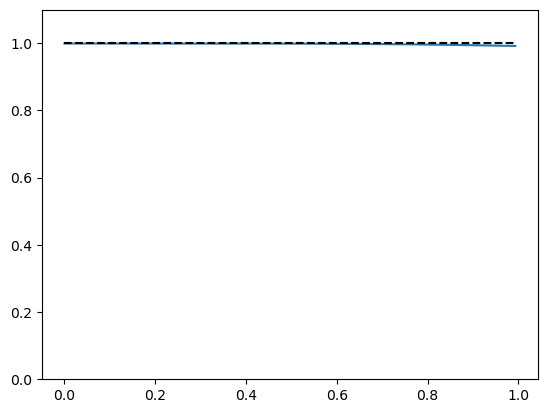

In [30]:
integrals = np.zeros(len(timestep_vals))
for i in np.arange(len(timestep_vals)):
    plot_unraveled = plots[:,0:(Nz-1),:,i].ravel()
    integrals[i] = np.sum(dx*dy*dz_weights*plot_unraveled)
print(f'mass at time t={timestep_vals[len(timestep_vals)-1]} is {np.round(integrals[len(integrals)-1]/integrals[0], 2)} times the original mass')
plt.plot(timestep_vals,integrals)
plt.plot([timestep_vals[0], timestep_vals[len(timestep_vals)-1]], [integrals[0],integrals[0]], linestyle='dashed',color='k')
plt.ylim([0,1.1])

